In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Suppresses most TF warnings/errors

import tensorflow as tf
# Explicitly allow memory growth to prevent "factory" registration crashes
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [ ]:
import pandas as pd
import time
import librosa
import librosa.effects
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from tslearn.shapelets import LearningShapelets, grabocka_params_to_shapelet_size_dict
from tslearn.preprocessing import TimeSeriesScalerMinMax, TimeSeriesResampler,TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans
import stumpy # Per Motif e Anomalies
from stumpy import motifs
from tslearn.utils import to_time_series_dataset
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Supervised Learning with Shapelets: Discriminative Pattern Discovery

While **Matrix Profiles** allowed us to identify *motifs* (the most repetitive patterns within an artist's repertoire), they do not necessarily tell us what distinguishes one artist from another. To solve this, we turn to **Shapelets**.

**Shapelets** are time-series subsequences that are maximally discriminative. Unlike motifs, which are found via unsupervised search, shapelets are learned in a supervised manner to maximize classification accuracy.

In this section, we utilize the **Learning Shapelets** algorithm (Grabocka et al.). Instead of a brute-force search, this method treats shapelets as learnable parameters of a neural network, allowing us to differentiably optimize the spectral "signatures" that best separate **Fedez** from **Fabri Fibra**.

### 1. Data Preparation and Scaling
We utilize the same preprocessing constraints as the motif analysis (central 60 seconds, MFCC features). However, `LearningShapelets` is sensitive to feature magnitudes. We apply **MinMax Scaling** to normalize the MFCC coefficients between 0 and 1, ensuring stable gradient descent.

In [5]:
# 1. Carica la matrice (veloce)
X = np.load("X_features_one_minute.npy")

# indices_to_keep = np.r_[0:13, 20:33]
indices_to_keep = np.r_[0:13] #only mfcc's
X = X[:, :, indices_to_keep]


df_processed = pd.read_csv('df_processed_1_minute.csv')
# 2. Prendi y_ok direttamente dal tuo df_processed (risolve il NameError)
y_ok = df_processed['id_artist'].values

print(f"Dati pronti! X shape: {X.shape}, y_ok: {len(y_ok)}")

Dati pronti! X shape: (443, 646, 13), y_ok: 443


In [7]:
scaler = TimeSeriesScalerMeanVariance(mu=0, std=1)
X_scaled = scaler.fit_transform(X)

In [8]:
# 1. Define your mapping (Who is 0 and who is 1?)
# Make sure the strings match exactly what is in your dataframe (check for lowercase)
artist_mapping = {
    'fedez': 0,
    'fabri fibra': 1
}

# 2. Create the labels
# We iterate through the dataframe to ensure the order matches X_final exactly
y_true = []

print("🏷️ Generating labels from 'name_artist'...")

for artist in df_processed['name_artist']:
    # Convert to lowercase to be safe
    clean_name = str(artist).lower().strip()

    if clean_name in artist_mapping:
        y_true.append(artist_mapping[clean_name])
    else:
        # Fallback if there's a typo or different name (e.g. "Fedez feat...")
        # You might want to print these to check
        if 'fedez' in clean_name:
            y_true.append(0)
        elif 'fibra' in clean_name:
            y_true.append(1)
        else:
            print(f"⚠️ Warning: Unknown artist '{artist}' found. Assigning -1.")
            y_true.append(-1)

# 3. Convert to Numpy Array
y_true = np.array(y_true)

# 4. Verification
print(f"✅ y_true created! Shape: {y_true.shape}")
print(f"   Count for Fedez (0): {np.sum(y_true == 0)}")
print(f"   Count for Fibra (1): {np.sum(y_true == 1)}")

# Check if X_final and y_true match in length
if 'X_final' in locals() and len(X) != len(y_true):
    print(f"❌ ERROR: Mismatch! X has {len(X)} items, but y_true has {len(y_true)}.")
else:
    print("✅ Lengths match perfectly with X.")

X_shape = to_time_series_dataset(X)
y_shape = y_true # 0 per Fedez, 1 per Fibra


🏷️ Generating labels from 'name_artist'...
✅ y_true created! Shape: (443,)
   Count for Fedez (0): 175
   Count for Fibra (1): 268
✅ Lengths match perfectly with X.


### Model Configuration: The "Grabocka" Parameters

The core of the Learning Shapelets algorithm relies on defining the number and length of the shapelets to be learned.

* **Shapelet Length ($L$):** We fix $L=22$ frames. At our hop length, this corresponds to approximately **2 seconds** of audio. This is long enough to capture a distinct phonetic phrase or rhythmic flow, but short enough to be generalizable.
* **Number of Shapelets ($K$):** We set $K=5$. By restricting the model to a small number of prototypes, we force it to learn only the most powerful discriminators rather than overfitting to noise.

In [9]:
# 1. Verifica e Scaling
# X_final shape: (448, 2584, 13)
# Il modello LearningShapelets beneficia enormemente dallo scaling MinMax (0, 1)
X_scaled_ls = TimeSeriesScalerMinMax().fit_transform(X)
X_scaled_ls = X_scaled_ls.astype('float32')

# 2. Estrazione dimensioni corrette
n_ts, ts_sz, n_features = X_scaled_ls.shape
n_classes = len(np.unique(y_true)) # Assicurati che y sia definito (es. i tuoi generi)

# 3. Calcolo parametri di Grabocka
# Nota: l=0.1 significa che la shapelet sarà lunga il 10% di 2584 (~258 punti)
# r=1 significa che usiamo una sola scala di lunghezza.
shapelet_sizes = grabocka_params_to_shapelet_size_dict(
    n_ts=n_ts,
    ts_sz=ts_sz,
    n_classes=n_classes,
    l=0.035,
    r=1
)

# shapelet_sizes = {
#     12: 3,  # Short: ~2 seconds (Specific sounds)
#     35: 3,  # Medium: ~5 seconds (Musical loops)
#     60: 3   # Long: ~9 seconds (Phrasing - might be harder to learn)
# }

print(f"Dimensioni: {n_ts} tracce, {ts_sz} sample, {n_features} feature")
print(f"Classi rilevate: {n_classes}")
print(f"Shapelet pianificate: {shapelet_sizes}")

Dimensioni: 443 tracce, 646 sample, 13 feature
Classi rilevate: 2
Shapelet pianificate: {22: 5}


### Training with K-Means Initialization

A common challenge with Learning Shapelets is getting stuck in local minima. To mitigate this, we employ a **two-phase initialization strategy**:

1.  **Fast Initialization:** We perform a quick fit on a small subset of the data. This effectively utilizes **K-Means** to initialize the shapelet weights near actual data centroids, rather than starting with random vectors.
2.  **Full Training:** We then train the model using the **Adam** optimizer. We employ **Early Stopping** (monitoring validation loss) to prevent overfitting and ensure the learned shapes generalize to unseen tracks.

In [ ]:
# 1. Split Data
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled_ls, y_true, test_size=0.2, random_state=42, stratify=y_true
)

# 2. Configure Model
custom_lr = 0.003
custom_optimizer = Adam(learning_rate=custom_lr)

shp_clf = LearningShapelets(
    n_shapelets_per_size=shapelet_sizes,
    optimizer=custom_optimizer,
    batch_size=8,
    weight_regularizer=0.1,
    max_iter=1,               # Only 1 iter needed for init
    random_state=42,
    verbose=1,
    scale=False
)

# 3. FAST Initialization (The Trick)
# We fit on a tiny slice (30 samples) just to build the internal layers and shapelets quickly.
print("🚀 Initializing model on subset (fast)...")
shp_clf.fit(X_train[:30], y_train[:30])
print("✅ Initialization complete. Model is built.")

🚀 Initializing model on subset (fast)...


/usr/local/lib/python3.12/dist-packages/tslearn/shapelets/shapelets.py:492: FutureWarning: The default value for 'scale' is set to False in version 0.4 to ensure backward compatibility, but is likely to change in a future version.
  warnings.warn("The default value for 'scale' is set to False "
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 448ms/step - binary_accuracy: 0.6575 - binary_crossentropy: 0.6533 - loss: 0.8738
✅ Initialization complete. Model is built.


In [ ]:
# --- SESSION 1: SAVE ---
# This saves the entire shp_clf object, including the trained weights and architecture
shp_clf.to_pickle("my_shapelet_model.pkl")
print("Model saved successfully using Pickle!")

# --- SESSION 2: LOAD (New start) ---

# One line to bring it back exactly as it was
new_shp_clf = LearningShapelets.from_pickle("my_shapelet_model.pkl")

Model saved successfully using Pickle!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [ ]:
# 2. Correzione delle dimensioni di Y per Keras
shp_clf = LearningShapelets.from_pickle("my_shapelet_model.pkl")

# 3. Definizione Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

learning_rates = [0.005]

for lr in learning_rates:
    print(f"\n--- Testing Learning Rate: {lr} ---")

    # 5. RE-COMPILE to rebuild the loss function from scratch
    shp_clf.model_.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['binary_accuracy']
    )


    # Train
    history = shp_clf.model_.fit(
        X_train, y_train,
        epochs=200,
        batch_size=8,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=1
    )

    print(f"Final Val Accuracy: {history.history['val_binary_accuracy'][-1]:.4f}")
    # 1. Reset model to the exact initial state

    # Record results (e.g., best validation accuracy)
    best_val_acc = max(history.history['val_binary_accuracy'])
    print(f"Best Val Accuracy for LR {lr}: {best_val_acc:.4f}")


--- Testing Learning Rate: 0.005 ---
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - binary_accuracy: 0.5924 - loss: 0.8658 - val_binary_accuracy: 0.6067 - val_loss: 0.7821
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.6015 - loss: 0.7755 - val_binary_accuracy: 0.6067 - val_loss: 0.7289
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.6015 - loss: 0.7287 - val_binary_accuracy: 0.6067 - val_loss: 0.6986
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.6015 - loss: 0.7012 - val_binary_accuracy: 0.6067 - val_loss: 0.6828
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.6015 - loss: 0.6861 - val_binary_accuracy: 0.6067 - val_loss: 0.6748
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.6015 - loss: 0.6783 - val_binary_accuracy: 0.6067 - val_loss: 0.6706
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.6015 - loss: 0.6742 - val_binary_accuracy: 

### Classification Performance

We evaluate the quality of the learned shapelets by analyzing the training history and the confusion matrix.
* **Loss/Accuracy Curves:** We look for convergence (loss decreasing) and a small gap between Training and Validation metrics to ensure the model isn't overfitting.
* **Confusion Matrix:** This confirms the model's practical ability to distinguish the two artists on the hold-out test set.

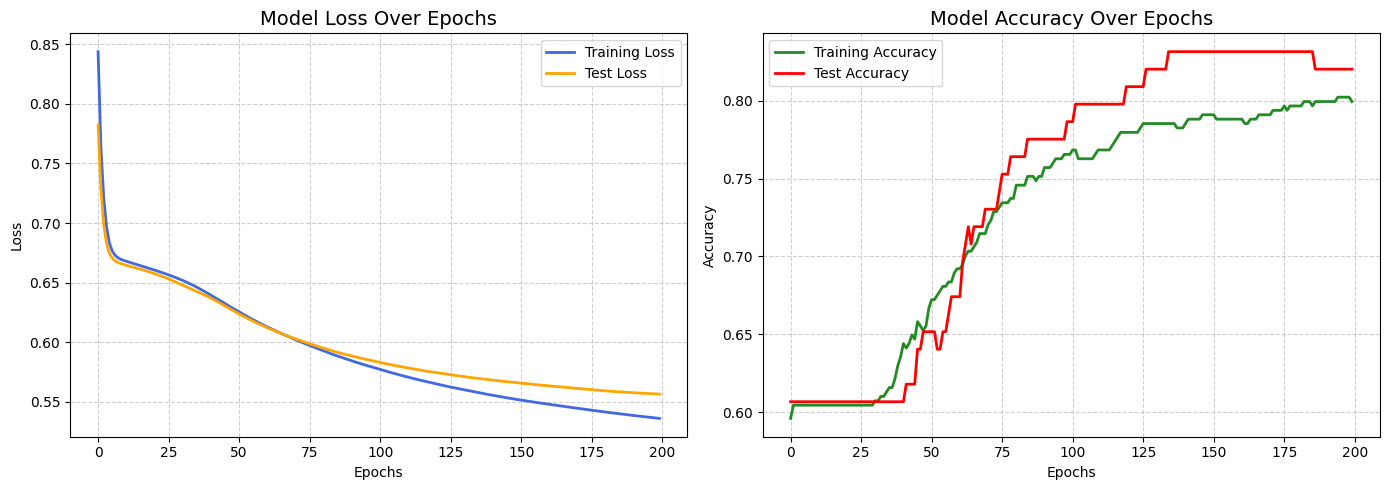

In [ ]:
# 1. Access the history dictionary
# tslearn stores the history in the .model_ attribute (which is the underlying Keras model)
history = shp_clf.model_.history.history

# 2. Create the plots
plt.figure(figsize=(14, 5))

# --- Plot Loss ---
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss', color='royalblue', linewidth=2)
if 'val_loss' in history:
    plt.plot(history['val_loss'], label='Test Loss', color='orange', linewidth=2)
plt.title('Model Loss Over Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Plot Accuracy ---
plt.subplot(1, 2, 2)
# Note: depending on your version, key might be 'accuracy' or 'binary_accuracy'
acc_key = 'accuracy' if 'accuracy' in history else 'binary_accuracy'
plt.plot(history[acc_key], label='Training Accuracy', color='forestgreen', linewidth=2)
if f'val_{acc_key}' in history:
    plt.plot(history[f'val_{acc_key}'], label='Test Accuracy', color='red', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


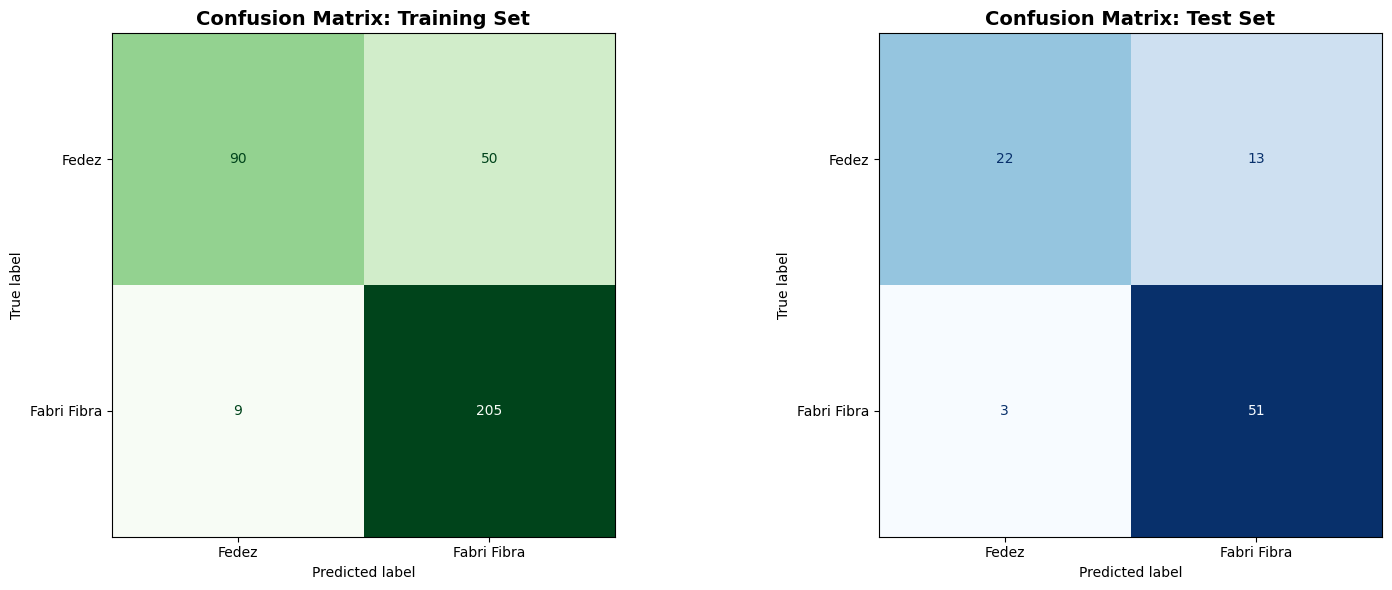

In [ ]:
# 1. Get predictions for both sets
# Training predictions
y_train_pred_probs = shp_clf.model_.predict(X_train)
y_train_pred = (y_train_pred_probs > 0.5).astype(int).flatten()

# Validation predictions
y_val_pred_probs = shp_clf.model_.predict(X_val)
y_val_pred = (y_val_pred_probs > 0.5).astype(int).flatten()

# 2. Compute Confusion Matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_val = confusion_matrix(y_val, y_val_pred)

# 3. Setup Plotting
display_labels = ['Fedez', 'Fabri Fibra']
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot Training Matrix
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=display_labels)
disp_train.plot(ax=ax[0], cmap='Greens', values_format='d', colorbar=False)
ax[0].set_title('Confusion Matrix: Training Set', fontsize=14, fontweight='bold')

# Plot Validation Matrix
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=display_labels)
disp_val.plot(ax=ax[1], cmap='Blues', values_format='d', colorbar=False)
ax[1].set_title('Confusion Matrix: Test Set', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Interpreting the Learned Signatures

Below, we visualize the learned weights as **Heatmaps**.

* **Y-Axis:** Represents the MFCC features (spectral envelope).
* **X-Axis:** Represents time (over the ~2 second window).

These heatmaps represent the *idealized* spectral patterns that the model looks for in every song.

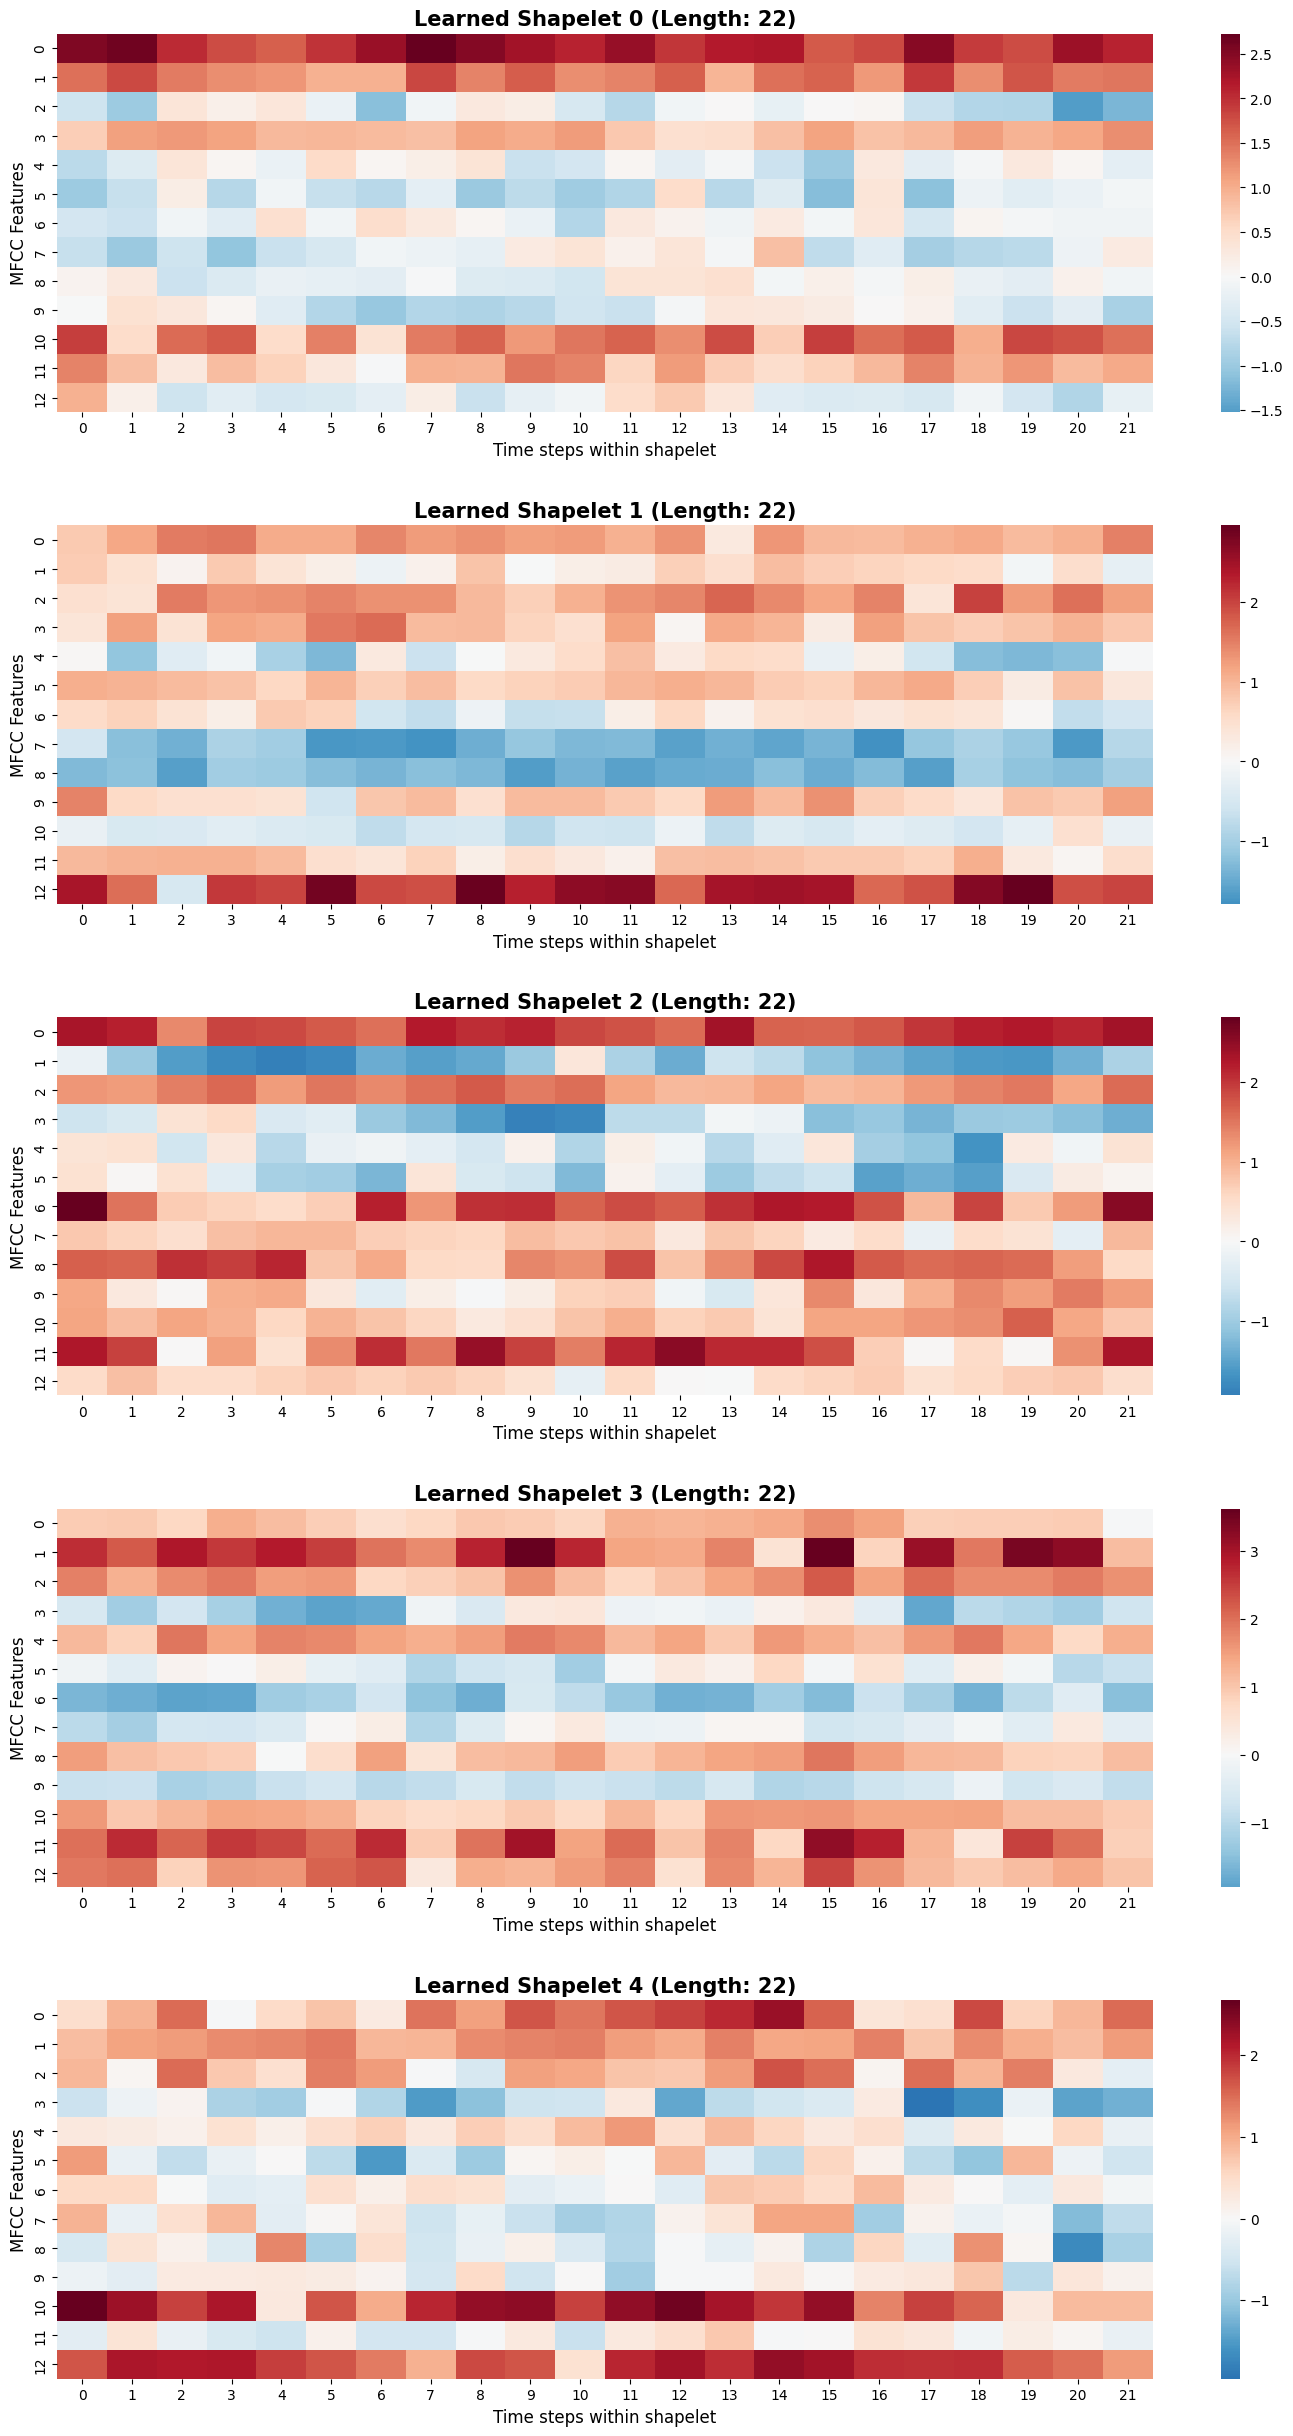

In [ ]:
# 1. Access the individual shapelets
shp_list = shp_clf.shapelets_
n_total = len(shp_list)

# 2. Plotting (One per row to make them large and interpretable)
plt.figure(figsize=(15, 5 * n_total))

for i, s in enumerate(shp_list):
    ax = plt.subplot(n_total, 1, i + 1)

    # Transpose (.T) so MFCC features are on the Y-axis and Time is on the X-axis
    sns.heatmap(s.T, cmap='RdBu_r', center=0, ax=ax)

    plt.title(f"Learned Shapelet {i} (Length: {s.shape[0]})", fontsize=15, fontweight='bold')
    plt.ylabel("MFCC Features", fontsize=12)
    plt.xlabel("Time steps within shapelet", fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
# Check which class is encoded as 1
le = LabelEncoder()
y_encoded = le.fit_transform(y_true) # Assuming you used something like this
print(f"Class 0: {le.classes_[0]}")
print(f"Class 1: {le.classes_[1]}")

print("\n--- Corrected Attribution Logic ---")
weights = shp_clf.model_.get_weights()[-2]

for i in range(len(shp_list)):
    w = weights[i][0]
    # Standard Logic: Negative weight favors Class 1, Positive favors Class 0
    if w < 0:
        predicted_artist = le.classes_[1] # The "Positive" Class
    else:
        predicted_artist = le.classes_[0] # The "Negative" Class

    print(f"Shapelet {i}: Predicts {predicted_artist} (Weight: {w:.4f})")

Class 0: 0
Class 1: 1

--- Corrected Attribution Logic ---
Shapelet 0: Predicts 0 (Weight: 0.5280)
Shapelet 1: Predicts 0 (Weight: 0.3172)
Shapelet 2: Predicts 1 (Weight: -0.3995)
Shapelet 3: Predicts 0 (Weight: 0.1801)
Shapelet 4: Predicts 1 (Weight: -0.3051)


### Localization: From Theory to Reality

The heatmaps above are "prototypes." We now use the `.locate()` method to find the specific moments in the actual dataset that best match these prototypes. This allows us to listen to the exact 2-second clip that the model considers the "Quintessential Fedez" or "Quintessential Fibra" moment.

In [38]:
# 1. Get Distances (How good is the match?) AND Locations (Where is it?)
distances = shp_clf.transform(X_scaled_ls)  # Shape: (n_songs, n_shapelets)
locations = shp_clf.locate(X_scaled_ls)     # Shape: (n_songs, n_shapelets)

# 2. Correct Audio Parameters (Verify these match your extraction!)
sample_rate = 22050
hop_length = 2048
seconds_per_index = hop_length / sample_rate

# 3. Filter for "Real" Matches
shapelet_id = 2  # Let's look at the first shapelet
target_artist_idx = 0

# Calculate a "good match" threshold (e.g., the average distance across dataset)
threshold = np.mean(distances[:, shapelet_id])

print(f"--- Strong Matches for Shapelet {shapelet_id} ---")

count = 0
for i in range(len(X_scaled_ls)):
    # Check Artist AND Match Quality
    dist = distances[i, shapelet_id]

    if y_true[i] == target_artist_idx and dist < threshold:
        count += 1
        start_idx = locations[i, shapelet_id]
        start_sec = start_idx * seconds_per_index
        end_sec = start_sec + (12 * seconds_per_index) # Assuming len 12

        song_name = df_processed.iloc[i]['title']
        print(f"Song: {song_name[:25]:<25} | Time: {start_sec:.1f}s - {end_sec:.1f}s | Quality: {dist:.4f}")

print(f"\nFound {count} strong matches out of {len(X_scaled_ls)} songs.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'min_pooling_0' (of type GlobalMinPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
--- Strong Matches for Shapelet 2 ---
Song: SEXY SHOP                 | Time: 14.6s - 15.7s | Quality: 18.0137
Song: Che cazzo ridi            | Time: 56.4s - 57.5s | Quality: 16.6246
Song: BELLA STORIA              | Time: 36.8s - 37.9s | Quality: 18.0196
Song: No Game Freestyle         | Time: 51.1s - 52.2s | Quality: 17.5781
Song: Prima di ogni cosa        | Time: 1.6s - 2.7s | Quality: 17.8588
Song: SAPORE                    | Time: 42.0s - 43.1s | Quality: 18.0463
Song: Si scrive schiavitù si le | Time: 4.9s - 6.0s | Quality: 17.8152
Song: Sembra semplice           | Time: 4.1s - 5.2s | Quality: 17.9171
Song: DISCO PARADISE            | Time: 43.1s - 44.2s | Quality: 17.3648
Song: VITTORIA                  | Time: 4.0s - 5.1s | Quality: 17.9351
Song: LE MADRI DEGLI ALTRI      | Time: 4.4s - 5.5s | Quality: 17.3640
Song: Non c’è due senza trash   | Time: 42.4s - 43.5s | Quality: 17.6598
Song: Sirene    

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


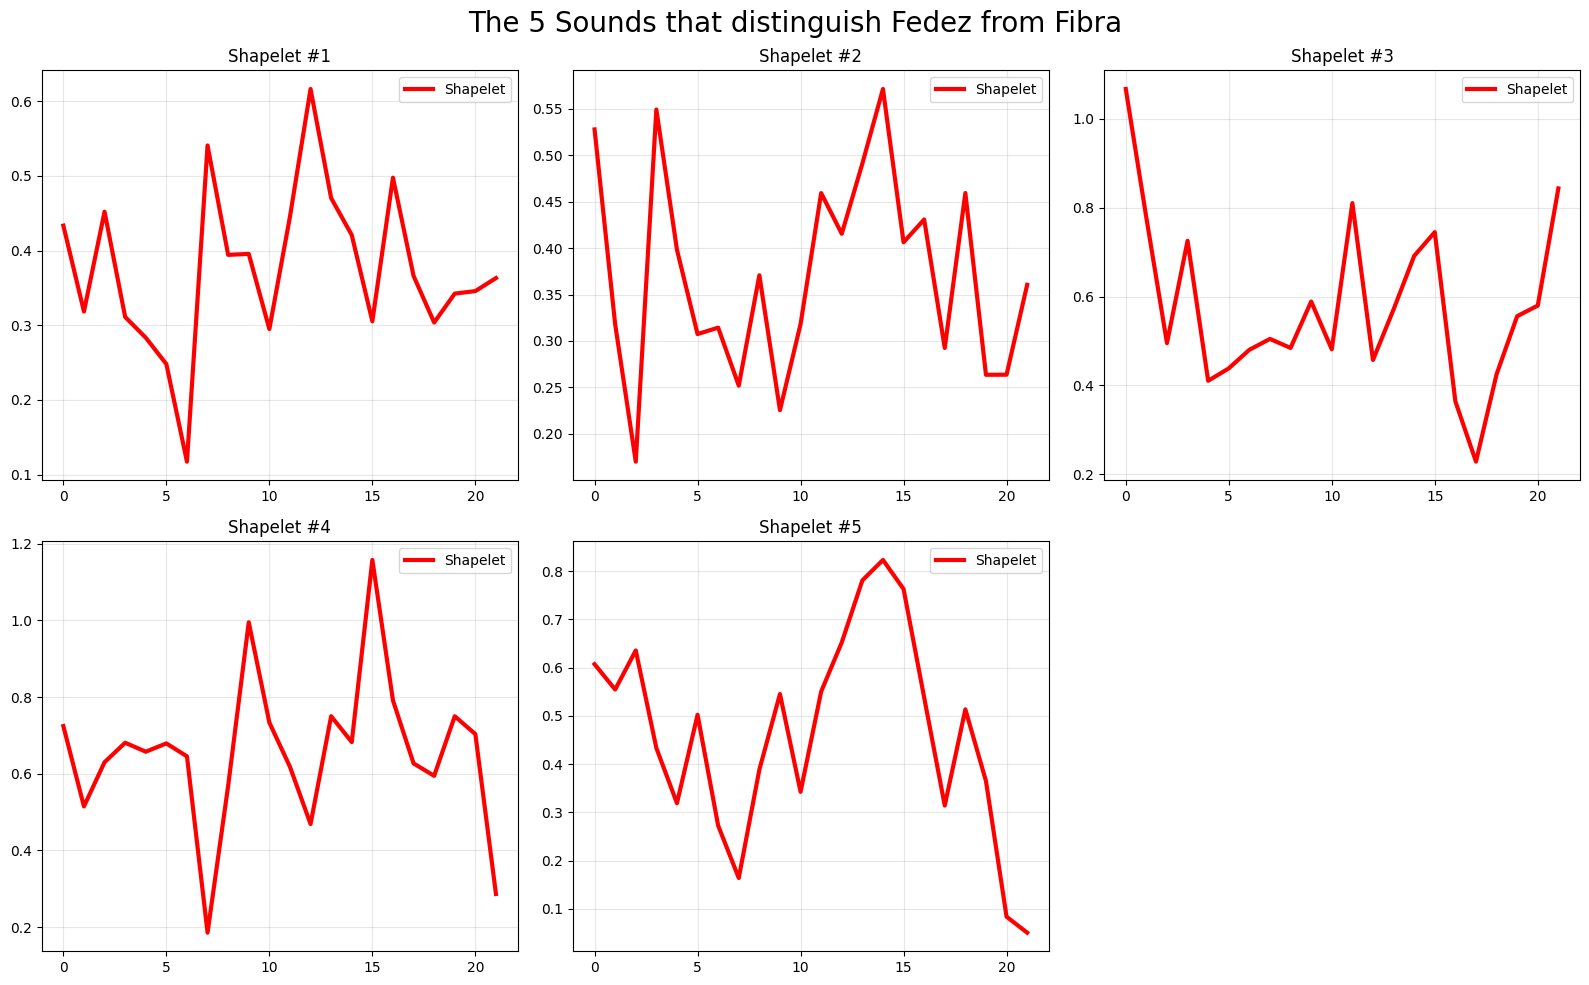

In [ ]:
# 1. Get the learned shapelets (The "Prototypical Patterns")
learned_shapelets = shp_clf.shapelets_as_time_series_

# 2. Find where they appear in the dataset
predicted_locations = shp_clf.locate(X_scaled_ls)

# 3. Plot them
plt.figure(figsize=(16, 10))
plt.suptitle(f"The 5 Sounds that distinguish Fedez from Fibra", fontsize=20)

for i in range(len(learned_shapelets)):
    # Find the best matching song for this shapelet
    best_match_idx = np.argmin(shp_clf.transform(X_scaled_ls)[:, i])

    # Get the data
    shapelet = learned_shapelets[i].flatten() # Flatten if 1D plot needed, or keep for heatmap

    # Create Subplot
    ax = plt.subplot(2, 3, i + 1)
    ax.set_title(f"Shapelet #{i+1}")

    # Plot the shapelet (using just the first MFCC coefficient for clarity if it's 2D)
    # If shapelet is (12, 26), we plot the mean envelope to keep it simple
    plt.plot(learned_shapelets[i].mean(axis=1), color='red', linewidth=3, label='Shapelet')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


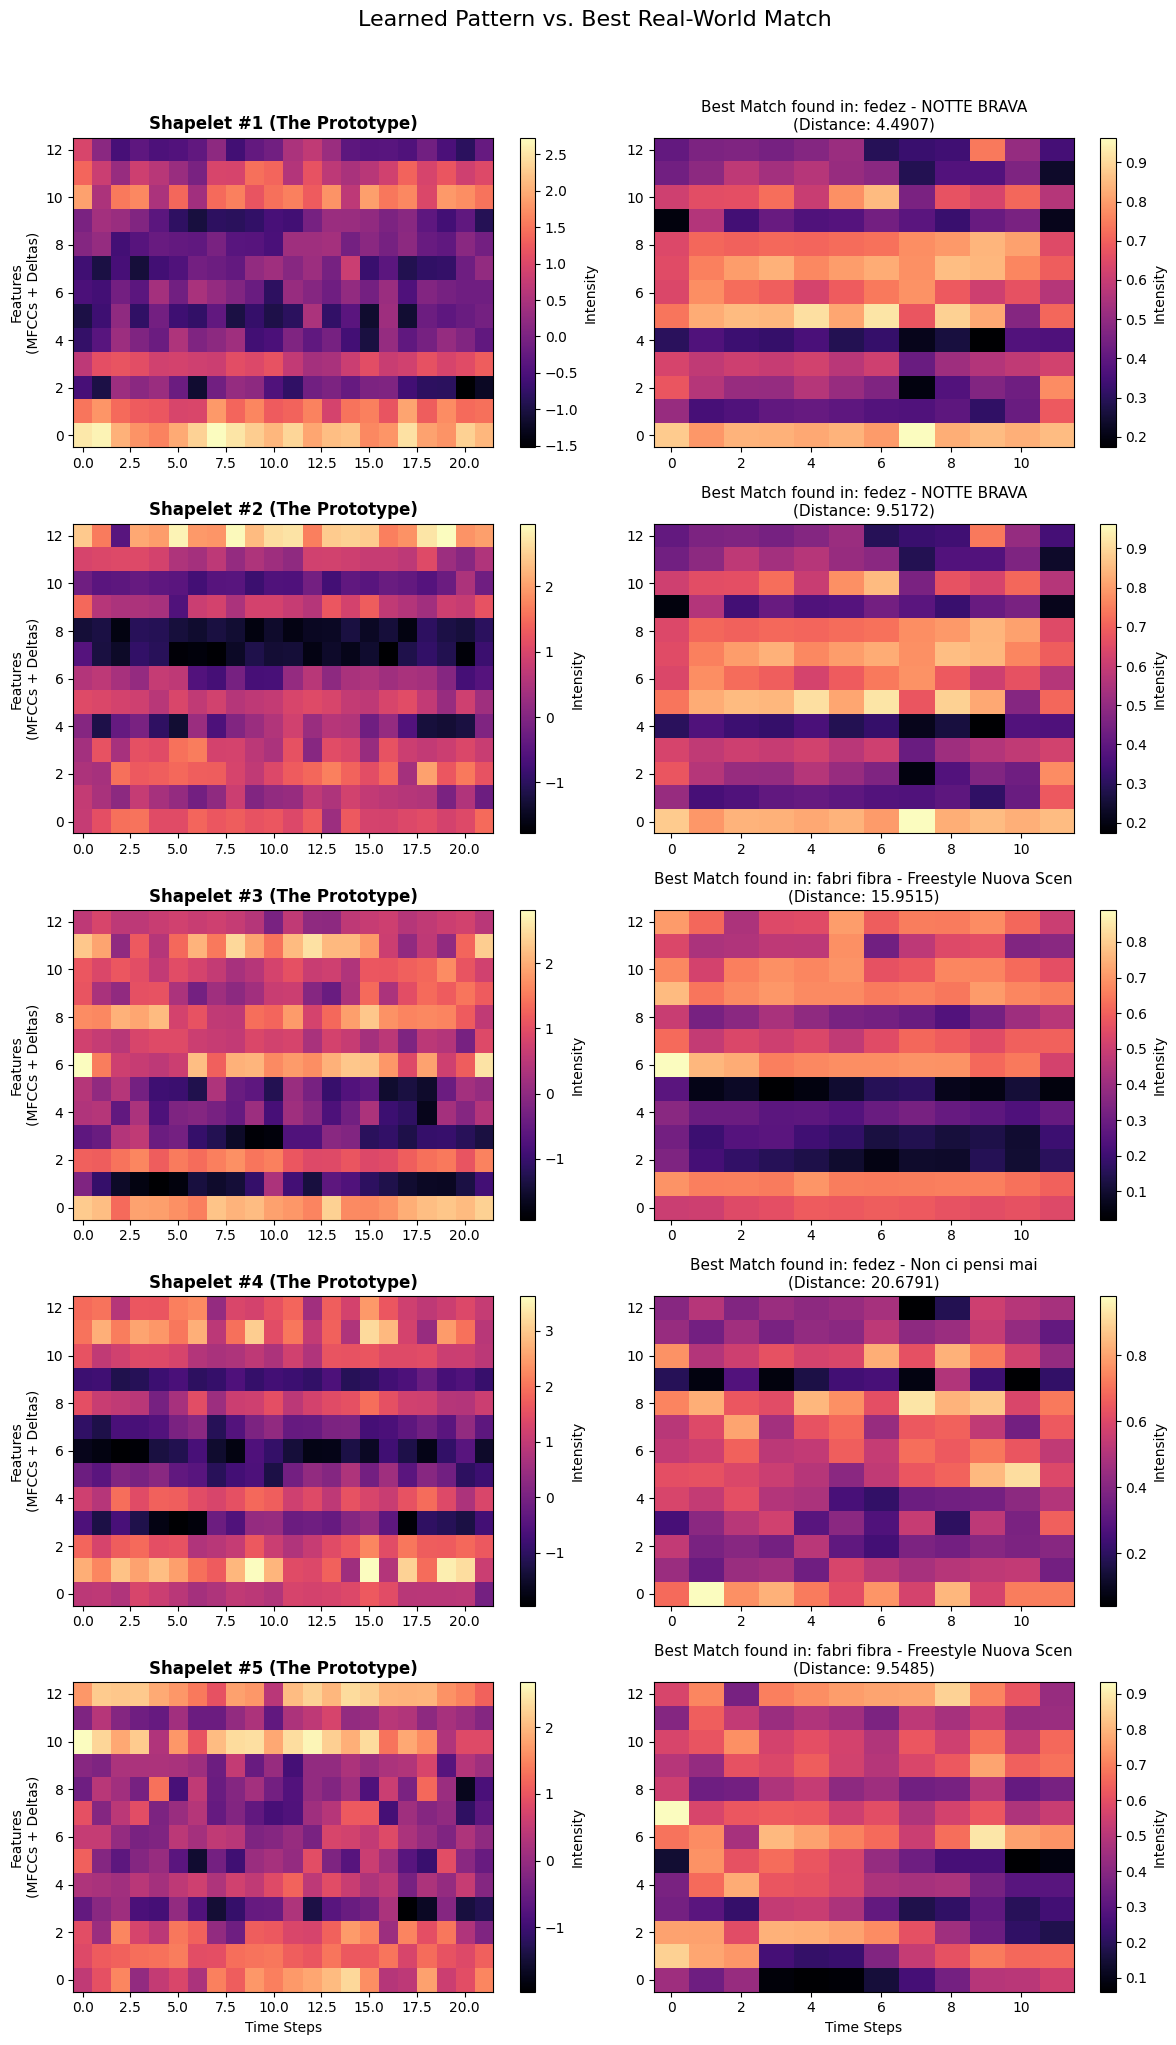

In [ ]:
# --- SETTINGS ---
# Assuming X_scaled_ls is your dataset and shp_clf is your trained model
learned_shapelets = shp_clf.shapelets_as_time_series_
predicted_locations = shp_clf.locate(X_scaled_ls)
distances = shp_clf.transform(X_scaled_ls)

# Setup the plot figure
n_shapelets = len(learned_shapelets)
plt.figure(figsize=(12, 4 * n_shapelets)) # Adjust height dynamically
plt.suptitle("Learned Pattern vs. Best Real-World Match", fontsize=16, y=1.02)

for i in range(n_shapelets):
    # 1. Find the best matching song (Index with lowest distance)
    best_song_idx = np.argmin(distances[:, i])
    min_dist = distances[best_song_idx, i]

    # 2. Get the match location
    start_step = predicted_locations[best_song_idx, i]

    # 3. Extract the "Real" segment from the dataset
    # We slice X at the exact moment the shapelet matched
    # Shape: (12, 26)
    real_segment = X_scaled_ls[best_song_idx, start_step : start_step + 12, :]

    # 4. Get the "Abstract" learned shapelet
    learned_pattern = learned_shapelets[i]

    # --- PLOTTING ---
    # Row i, Column 1: The Learned Shapelet
    ax1 = plt.subplot(n_shapelets, 2, i * 2 + 1)
    # Transpose (.T) so Time is X-axis, MFCCs are Y-axis
    plt.imshow(learned_pattern.T, aspect='auto', cmap='magma', origin='lower', interpolation='nearest')
    plt.title(f"Shapelet #{i+1} (The Prototype)", fontsize=12, fontweight='bold')
    plt.ylabel(f"Features\n(MFCCs + Deltas)")
    if i == n_shapelets - 1: plt.xlabel("Time Steps")
    plt.colorbar(label="Intensity")

    # Row i, Column 2: The Real Data Match
    ax2 = plt.subplot(n_shapelets, 2, i * 2 + 2)
    plt.imshow(real_segment.T, aspect='auto', cmap='magma', origin='lower', interpolation='nearest')

    # Add metadata to title
    song_title = df_processed.iloc[best_song_idx]['title'][:20] # Shorten title
    artist = df_processed.iloc[best_song_idx]['name_artist']
    plt.title(f"Best Match found in: {artist} - {song_title}\n(Distance: {min_dist:.4f})", fontsize=11)

    if i == n_shapelets - 1: plt.xlabel("Time Steps")
    plt.colorbar(label="Intensity")

plt.tight_layout()
plt.show()

In [ ]:
# --- SETTINGS ---
hop_length = 2048
sr = 22050
CLIP_DURATION = 60
TOP_K = 5

# 1. Get Distances and Locations
distances = shp_clf.transform(X_scaled_ls)
locations = shp_clf.locate(X_scaled_ls)

top_matches_registry = {}

print(f"🔎 Finding Top {TOP_K} matches (with Track Indices)...\n")

for i in range(len(shp_clf.shapelets_as_time_series_)):
    print(f"--- SHAPELET #{i+1} ---")

    # Sort indices by distance (best to worst)
    sorted_indices = np.argsort(distances[:, i])
    top_indices = sorted_indices[:TOP_K]

    shapelet_matches = []

    for rank, song_idx in enumerate(top_indices):
        dist = distances[song_idx, i]
        row = df_processed.iloc[song_idx]

        # --- GET TRACK ID ---
        # Option A: Use the numeric DataFrame index (Always works)
        track_identifier = f"Index_{song_idx}"

        # Option B: Use a real ID column if you have one (e.g., 'track_id', 'id')
        # if 'track_id' in row: track_identifier = row['track_id']

        # --- TIMING CALCULATION ---
        start_step = locations[song_idx, i]
        start_sec_rel = (start_step * hop_length) / sr
        shapelet_duration = (12 * hop_length) / sr

        # Handle 60s Crop Offset
        if 'duration_sec' in row:
            total_duration = row['duration_sec']
        else:
            total_duration = librosa.get_duration(path=row['file_path'])

        if total_duration > CLIP_DURATION:
            offset_start = (total_duration - CLIP_DURATION) / 2
        else:
            offset_start = 0

        abs_start_time = offset_start + start_sec_rel
        abs_end_time = abs_start_time + shapelet_duration

        # --- PRINT WITH INDEX ---
        print(f"   {rank+1}. [{row['track_id']}] {row['name_artist']} - {row['title']}")
        print(f"      📍 Time: {abs_start_time:.1f}s - {abs_end_time:.1f}s  (Dist: {dist:.4f})")

        match_info = {
            "track_index": song_idx,        # Numeric index for lookup
            "track_id": row['track_id'],   # String ID for display
            "artist": row['name_artist'],
            "title": row['title'],
            "start_time": abs_start_time,
            "end_time": abs_end_time,
            "distance": dist
        }
        shapelet_matches.append(match_info)

    top_matches_registry[i] = shapelet_matches
    print("")

print("✅ Done! Access results via `top_matches_registry`.")

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
🔎 Finding Top 5 matches (with Track Indices)...

--- SHAPELET #1 ---
   1. [TR459679] fedez - NOTTE BRAVA
      📍 Time: 104.9s - 106.0s  (Dist: 4.4907)
   2. [TR700059] fedez - Non ci pensi mai
      📍 Time: 91.7s - 92.8s  (Dist: 4.9191)
   3. [TR353282] fedez - MORIRE MORIRE
      📍 Time: 61.9s - 63.0s  (Dist: 5.1952)
   4. [TR446619] fabri fibra - Andiamo
      📍 Time: 138.1s - 139.2s  (Dist: 5.2718)
   5. [TR978886] fedez - L’arte di accontentare
      📍 Time: 129.9s - 131.0s  (Dist: 5.3119)

--- SHAPELET #2 ---
   1. [TR459679] fedez - NOTTE BRAVA
      📍 Time: 104.9s - 106.0s  (Dist: 9.5172)
   2. [TR446619] fabri fibra - Andiamo
      📍 Time: 137.9s - 139.0s  (Dist: 9.8939)
   3. [TR731379] fedez - Record
      📍 Time: 75.1s - 76.2s  (Dist: 10.0307)
   4. [TR700059] fedez - Non ci pensi mai
      📍 Time: 91.8s - 93.0s  (Dist: 10.1411)
   5. [TR393241] fedez - 21 Grammi
      📍 Time: 133.5s - 134.6s  (Di

### The "Signature" Test: Distance Distributions

To verify the discriminative power of a shapelet, we analyze the distribution of **Minimum Euclidean Distances** for the entire dataset.

A perfect discriminator will show a **Bimodal Distribution**:
* The "Owner" class will have a peak at **Low Distance** (strong match).
* The "Opposing" class will have a peak at **High Distance** (no match).

We calculate an optimal threshold (via a Decision Stump) to measure the "Gap" or discriminative power of each shapelet.

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


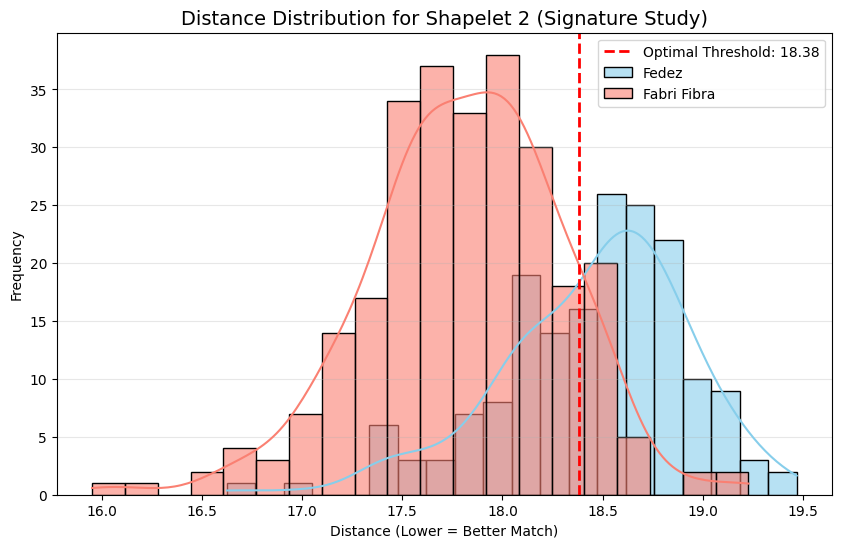

--- Task 4.2: Shapelet Coverage & Discriminative Power ---
Shapelet 0 (Owner: Fedez):
  > Weight: 0.5280
  > Fedez Coverage: 78.9%
  > Fibra Coverage: 13.4%
  > Gap (Discriminative Power): 65.4%
------------------------------
Shapelet 1 (Owner: Fedez):
  > Weight: 0.3172
  > Fedez Coverage: 70.9%
  > Fibra Coverage: 11.9%
  > Gap (Discriminative Power): 58.9%
------------------------------
Shapelet 2 (Owner: Fabri Fibra):
  > Weight: -0.3995
  > Fedez Coverage: 35.4%
  > Fibra Coverage: 88.8%
  > Gap (Discriminative Power): 53.4%
------------------------------
Shapelet 3 (Owner: Fedez):
  > Weight: 0.1801
  > Fedez Coverage: 81.7%
  > Fibra Coverage: 16.4%
  > Gap (Discriminative Power): 65.3%
------------------------------
Shapelet 4 (Owner: Fabri Fibra):
  > Weight: -0.3051
  > Fedez Coverage: 33.1%
  > Fibra Coverage: 88.8%
  > Gap (Discriminative Power): 55.7%
------------------------------


In [ ]:
# --- 1. Calculate All Distances ---
# Shape: (n_songs, n_shapelets)
distances = shp_clf.transform(X_scaled_ls)

# --- 2. Calculate Smart Thresholds via Decision Stumps ---
smart_thresholds = []
for i in range(distances.shape[1]):
    X_d = distances[:, i].reshape(-1, 1)
    stump = DecisionTreeClassifier(max_depth=1).fit(X_d, y_true)
    smart_thresholds.append(stump.tree_.threshold[0])

# --- 3. Plot Distance Distribution for Shapelet 2 ---
target_shp = 2
fedez_dists = distances[y_true == 0, target_shp]
fibra_dists = distances[y_true == 1, target_shp]

plt.figure(figsize=(10, 6))
sns.histplot(fedez_dists, color="skyblue", label="Fedez", kde=True, bins=20, alpha=0.6)
sns.histplot(fibra_dists, color="salmon", label="Fabri Fibra", kde=True, bins=20, alpha=0.6)

plt.axvline(smart_thresholds[target_shp], color='red', linestyle='--', linewidth=2,
            label=f'Optimal Threshold: {smart_thresholds[target_shp]:.2f}')

plt.title(f'Distance Distribution for Shapelet {target_shp} (Signature Study)', fontsize=14)
plt.xlabel('Distance (Lower = Better Match)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- 4. Calculate and Print Coverage Ratios ---
print("--- Task 4.2: Shapelet Coverage & Discriminative Power ---")

# Extract the final layer weights (the coefficients that multiply the distances)
# shp_clf.get_weights()[-2] is usually the (n_shapelets, 1) weight matrix
all_params = shp_clf.get_weights()
final_weights = all_params[-2].flatten()

for i in range(len(smart_thresholds)):
    # A "match" is any song where distance < threshold
    matches = distances[:, i] < smart_thresholds[i]

    # Calculate coverage for each artist
    fedez_cov = np.mean(matches[y_true == 0]) * 100
    fibra_cov = np.mean(matches[y_true == 1]) * 100

    # Corrected Logic:
    # Positive weights favor Class 0 (Fedez)
    # Negative weights favor Class 1 (Fabri Fibra)
    current_w = final_weights[i]
    owner = "Fedez" if current_w > 0 else "Fabri Fibra"

    print(f"Shapelet {i} (Owner: {owner}):")
    print(f"  > Weight: {current_w:.4f}")
    print(f"  > Fedez Coverage: {fedez_cov:.1f}%")
    print(f"  > Fibra Coverage: {fibra_cov:.1f}%")
    print(f"  > Gap (Discriminative Power): {abs(fedez_cov - fibra_cov):.1f}%")
    print("-" * 30)

### Cross-Analysis: Do Motifs equal Shapelets?

Finally, we test a key hypothesis: **Are the most frequent patterns (Motifs) also the most discriminative (Shapelets)?**

To do this, we:
1.  Generate a **Motif Book** containing the most repetitive sequences found in the unsupervised stage.
2.  Calculate the distance between every learned **Shapelet** and every entry in the **Motif Book**.

If the distance is low, it implies the artist's "signature" is a repetitive loop. If the distance is high, it suggests the signature is a subtle, less frequent nuance that defines their style.

In [ ]:
m = 22
n_motifs_per_song = 3
motif_book = []      # Inizializzazione come lista
motif_metadata = []

print("Estrazione motif con cutoff dinamico e min_neighbors=1...")

for i in range(X_scaled.shape[0]):
    # Estrazione dati canzone e metadati
    song_data = X_scaled[i].astype(np.float64)
    artist = df_processed.iloc[i]['name_artist']
    song_title = df_processed.iloc[i]['title']
    track_id = df_processed.iloc[i]['track_id']

    # 1. Calcolo Matrix Profile
    song_mean = song_data.mean(axis=1)
    mp = stumpy.stump(song_mean, m=m)

    # 2. Calcolo Cutoff Dinamico
    # Sostituisci il calcolo del cutoff con questo:
    min_dist = np.amin(mp[:, 0])

    # Se min_dist è 0, usiamo una piccola costante, altrimenti raddoppiamo il minimo
    calc_cutoff = max(min_dist * 2.0, 0.1)

    # 3. Ricerca Motif
    # min_neighbors=1: il pattern deve ripetersi almeno una volta per essere un motif
    match_distances, match_indices = motifs(
        song_mean,
        mp[:, 0],
        max_motifs=n_motifs_per_song,
        cutoff=calc_cutoff,
        min_neighbors=1
    )

    # 4. Popolamento del Book
    for idx_list in match_indices:
        if len(idx_list) > 0:
            best_idx = idx_list[0]

            # Segmento con tutte le feature (es. 60)
            motif_segment = song_data[best_idx : best_idx + m, :]

            # Aggiungiamo alla lista (appiattito per il clustering)
            motif_book.append(motif_segment.flatten())
            motif_metadata.append({
                'artist': artist,
                'song': song_title,
                'index': best_idx,
                'track_id': track_id
            })

# 5. Conversione finale in array NumPy
motif_book = np.array(motif_book)

print(f"✅ Book creato!")
print(f"   - Totale motif estratti: {len(motif_book)}")
print(f"   - Shape finale: {motif_book.shape}")

Estrazione motif con cutoff dinamico e min_neighbors=1...
✅ Book creato!
   - Totale motif estratti: 1326
   - Shape finale: (1326, 286)


Inizio confronto: 1326 motif vs 5 shapelet...


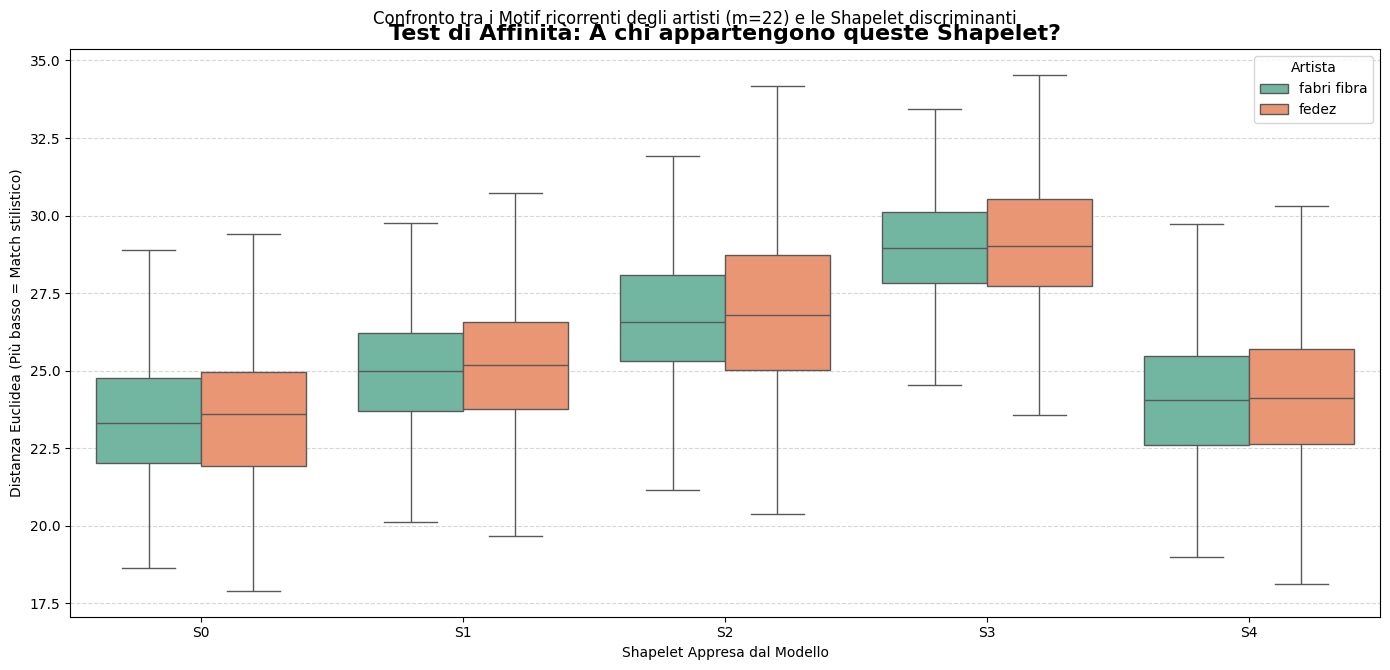

In [44]:
# --- 1. RECUPERO DATI ---

# Le tue shapelet (Lunghezza 22)
shapelets = shp_clf.shapelets_as_time_series_
n_shapelets = len(shapelets)

# Assicuriamoci che motif_book sia un array numpy (se non lo è già)
motif_book_arr = np.array(motif_book)

# Container per i risultati
results = []

print(f"Inizio confronto: {len(motif_book_arr)} motif vs {n_shapelets} shapelet...")

# --- 2. CALCOLO DISTANZE ---

for i, flat_motif in enumerate(motif_book_arr):
    # Recupera i metadati corrispondenti
    artist = motif_metadata[i]['artist']

    # Reshape del motif: Da piatto a (22, 13)
    # Nota: Assicurati che 13 sia il numero corretto di feature (MFCC)
    motif_real = flat_motif.reshape(22, -1)

    # Confronta questo motif con TUTTE le shapelet
    for s_idx, shapelet in enumerate(shapelets):

        # --- GESTIONE FEATURE ---
        # Se le shapelet hanno 26 feature (MFCC+Delta) e i motif 13,
        # tagliamo le shapelet per confrontare "mele con mele".
        n_feat_common = min(motif_real.shape[1], shapelet.shape[1])

        motif_comp = motif_real[:, :n_feat_common]
        shp_comp = shapelet[:, :n_feat_common]

        # --- CALCOLO DISTANZA (Norma di Frobenius) ---
        dist = np.linalg.norm(motif_comp - shp_comp)

        results.append({
            'Artist': artist,
            'Shapelet_ID': f"S{s_idx}", # Es. "S0", "S1"...
            'Distance': dist
        })

# Creiamo il DataFrame
df_dist = pd.DataFrame(results)

# --- 3. VISUALIZZAZIONE (BOXPLOT) ---

plt.figure(figsize=(14, 7))

# Boxplot:
# X = Quale Shapelet stiamo analizzando
# Y = Quanto sono distanti i motif degli artisti da essa
# Hue = Separa Fedez da Fibra (o altri artisti)
sns.boxplot(data=df_dist,
            x='Shapelet_ID',
            y='Distance',
            hue='Artist',
            palette="Set2",
            showfliers=False) # Nasconde gli outlier estremi per pulizia

plt.title("Test di Affinità: A chi appartengono queste Shapelet?", fontsize=16, fontweight='bold')
plt.suptitle("Confronto tra i Motif ricorrenti degli artisti (m=22) e le Shapelet discriminanti", fontsize=12, y=0.95)
plt.ylabel("Distanza Euclidea (Più basso = Match stilistico)")
plt.xlabel("Shapelet Appresa dal Modello")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Artista', loc='upper right')

plt.tight_layout()
plt.show()